In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

In [2]:
X, y = fetch_openml(name='house_prices', as_frame=True, return_X_y=True)
y = y.astype(float)

print(f'Размер матрицы признаков: {X.shape}')
print(f'Размер целевого вектора: {y.shape}')
print(f'Целевая переменная: {y.name}')

X.head()

Размер матрицы признаков: (1460, 80)
Размер целевого вектора: (1460,)
Целевая переменная: SalePrice


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [3]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f'Числовых признаков: {len(numeric_features)}')
print(f'Категориальных признаков: {len(categorical_features)}')
print('Примеры числовых признаков:', numeric_features[:10])
print('Примеры категориальных признаков:', categorical_features[:10])

Числовых признаков: 37
Категориальных признаков: 43
Примеры числовых признаков: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']
Примеры категориальных признаков: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


In [4]:
target_description = y.describe().to_frame(name='SalePrice')
target_description

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


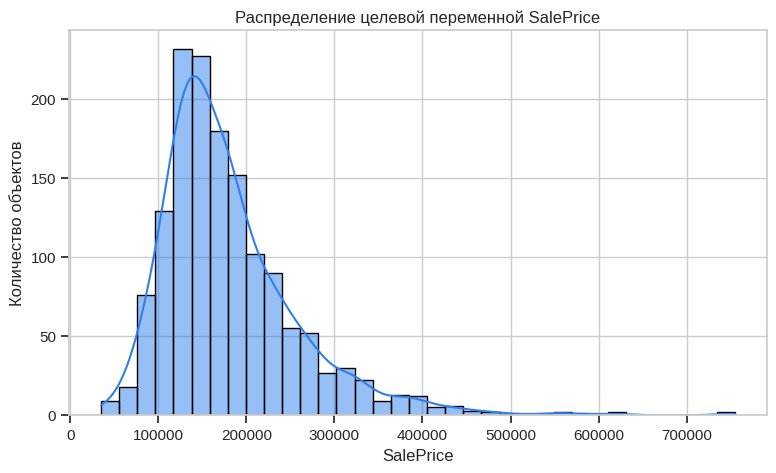

In [5]:
plt.figure(figsize=(9, 5))
sns.histplot(y, kde=True, bins=35, color='#2F80ED')
plt.title('Распределение целевой переменной SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Количество объектов')
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка: {X_test.shape}')

Обучающая выборка: (1168, 80)
Тестовая выборка: (292, 80)


- `RMSE`: корень из средней квадратичной ошибки, сильнее штрафует большие ошибки.
- `MAE`: средняя абсолютная ошибка, более интерпретируема в единицах цены.
- `R2`: доля объясненной дисперсии, чем ближе к 1, тем лучше.


In [7]:
def evaluate_model(name, model, X_train_data, y_train_data, X_test_data, y_test_data):
    """Обучает модель и возвращает основные метрики на тестовой выборке."""
    model.fit(X_train_data, y_train_data)
    predictions = model.predict(X_test_data)
    return {
        'model': name,
        'RMSE': mean_squared_error(y_test_data, predictions) ** 0.5,
        'MAE': mean_absolute_error(y_test_data, predictions),
        'R2': r2_score(y_test_data, predictions),
    }

results = []

In [8]:
numeric_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

linear_numeric_model = Pipeline(steps=[
    ('preprocess', numeric_preprocessor),
    ('model', LinearRegression()),
])

linear_numeric_result = evaluate_model(
    'LinearRegression: only numeric features',
    linear_numeric_model,
    X_train[numeric_features],
    y_train,
    X_test[numeric_features],
    y_test,
)
results.append(linear_numeric_result)
pd.DataFrame(results)

,model,RMSE,MAE,R2
0,LinearRegression: only numeric features,36882.493754,23001.73109,0.822652


In [9]:
boosting_numeric_model = Pipeline(steps=[
    ('preprocess', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
    )),
])

param_grid = {
    'model__n_estimators': [200, 500],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.03, 0.06],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__reg_lambda': [1.0, 5.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=boosting_numeric_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train[numeric_features], y_train)

print('Лучшие параметры:')
print(grid_search.best_params_)
print(f'Лучший CV RMSE: {-grid_search.best_score_:.2f}')

Fitting 5 folds for each of 96 candidates, totalling 480 fits


Лучшие параметры:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.06, 'model__max_depth': 2, 'model__n_estimators': 500, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}
Лучший CV RMSE: 27454.19


### Пояснение к следующей ячейке: оценка лучшего бустинга на test

`grid_search.best_estimator_` — это pipeline с лучшей комбинацией гиперпараметров по кросс-валидации.

Здесь модель уже обучена на train внутри `GridSearchCV`, поэтому можно сразу прогнозировать test. Метрики добавляются в общий список `results`, чтобы сравнить бустинг с линейной регрессией.

Обычно бустинг выигрывает на табличных данных, потому что деревья умеют моделировать нелинейности, пороговые эффекты и взаимодействия признаков.


In [10]:
best_boosting_numeric = grid_search.best_estimator_
boosting_numeric_result = {
    'model': 'XGBRegressor: only numeric features, tuned',
    'RMSE': mean_squared_error(y_test, best_boosting_numeric.predict(X_test[numeric_features])) ** 0.5,
    'MAE': mean_absolute_error(y_test, best_boosting_numeric.predict(X_test[numeric_features])),
    'R2': r2_score(y_test, best_boosting_numeric.predict(X_test[numeric_features])),
}
results.append(boosting_numeric_result)
pd.DataFrame(results).sort_values('RMSE')

,model,RMSE,MAE,R2
1,"XGBRegressor: only numeric features, tuned",27301.760820,17469.153414,0.902822
0,LinearRegression: only numeric features,36882.493754,23001.731090,0.822652


,model,RMSE,MAE,R2
1,"XGBRegressor: only numeric features, tuned",27301.760820,17469.153414,0.902822
0,LinearRegression: only numeric features,36882.493754,23001.731090,0.822652


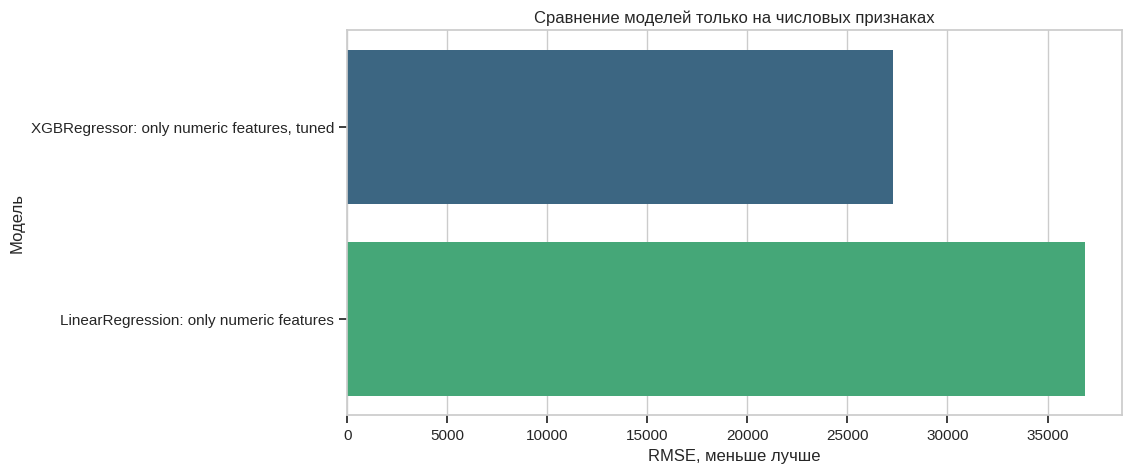

In [11]:
comparison_numeric = pd.DataFrame(results).sort_values('RMSE')
display(comparison_numeric)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_numeric, x='RMSE', y='model', palette='viridis')
plt.title('Сравнение моделей только на числовых признаках')
plt.xlabel('RMSE, меньше лучше')
plt.ylabel('Модель')
plt.show()

In [12]:
one_hot_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_features),
    ],
    remainder='drop',
)

one_hot_boosting_model = Pipeline(steps=[
    ('preprocess', one_hot_preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
        n_estimators=grid_search.best_params_['model__n_estimators'],
        max_depth=grid_search.best_params_['model__max_depth'],
        learning_rate=grid_search.best_params_['model__learning_rate'],
        subsample=grid_search.best_params_['model__subsample'],
        colsample_bytree=grid_search.best_params_['model__colsample_bytree'],
        reg_lambda=grid_search.best_params_['model__reg_lambda'],
    )),
])

one_hot_result = evaluate_model(
    'XGBRegressor: numeric + categorical OneHot',
    one_hot_boosting_model,
    X_train,
    y_train,
    X_test,
    y_test,
)
results.append(one_hot_result)
pd.DataFrame(results).sort_values('RMSE')

,model,RMSE,MAE,R2
2,XGBRegressor: numeric + categorical OneHot,25122.196392,16049.069791,0.917719
1,"XGBRegressor: only numeric features, tuned",27301.760820,17469.153414,0.902822
0,LinearRegression: only numeric features,36882.493754,23001.731090,0.822652


## Target encoding без утечки данных

Ниже реализован собственный `TargetEncoderRegressor`. Важный момент: при `fit_transform` на обучающей выборке используются out-of-fold значения, то есть объект кодируется статистикой, посчитанной на других фолдах. Это защищает от прямой утечки `y` в признаки.

Для тестовой выборки применяются статистики, рассчитанные на всей обучающей выборке. Для редких или новых категорий используется сглаживание к глобальному среднему.


### Пояснение к следующей ячейке: собственный TargetEncoderRegressor

Target encoding заменяет категорию числом, связанным со средним значением целевой переменной для этой категории. Например, район с дорогими домами получает более высокий код.

Главный риск target encoding — утечка целевой переменной. Если кодировать обучающий объект средним, посчитанным с участием самого этого объекта, модель может получить слишком оптимистичные признаки.

Поэтому класс реализует out-of-fold кодирование:

- в `fit_transform` обучающая выборка делится на фолды;
- для каждого фолда статистики категорий считаются только на остальных фолдах;
- объекты текущего фолда получают код, рассчитанный без них;
- после OOF-кодирования вызывается `fit`, чтобы сохранить финальные статистики для будущего `transform` на test.

Класс наследуется от `BaseEstimator` и `TransformerMixin`, чтобы работать внутри `Pipeline` и `ColumnTransformer` как обычный трансформер scikit-learn.


In [13]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoderRegressor(BaseEstimator, TransformerMixin):
    """Target encoding для регрессии с out-of-fold кодированием на train.

    Параметр smoothing управляет силой сглаживания: чем он больше,
    тем сильнее значение категории притягивается к глобальному среднему.
    """

    def __init__(self, categorical_columns, n_splits=5, smoothing=10.0, random_state=42):
        self.categorical_columns = categorical_columns
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.random_state = random_state

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y).reset_index(drop=True)
        X = X.reset_index(drop=True)
        self.global_mean_ = float(y.mean())
        self.mapping_ = {}

        for col in self.categorical_columns:
            stats = pd.DataFrame({'category': X[col].astype('object').fillna('__MISSING__'), 'target': y})
            grouped = stats.groupby('category')['target'].agg(['mean', 'count'])
            smooth = (grouped['count'] * grouped['mean'] + self.smoothing * self.global_mean_) / (grouped['count'] + self.smoothing)
            self.mapping_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        transformed = pd.DataFrame(index=X.index)
        for col in self.categorical_columns:
            values = X[col].astype('object').fillna('__MISSING__')
            transformed[col + '_target_encoded'] = values.map(self.mapping_[col]).fillna(self.global_mean_).astype(float)
        return transformed

    def fit_transform(self, X, y=None, **fit_params):
        if y is None:
            raise ValueError('TargetEncoderRegressor requires y for fit_transform.')

        X = pd.DataFrame(X).copy().reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)
        encoded = pd.DataFrame(index=X.index)
        self.global_mean_ = float(y.mean())

        cv = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for col in self.categorical_columns:
            encoded[col + '_target_encoded'] = np.nan
            values = X[col].astype('object').fillna('__MISSING__')

            for train_idx, valid_idx in cv.split(X):
                train_values = values.iloc[train_idx]
                train_target = y.iloc[train_idx]
                valid_values = values.iloc[valid_idx]

                stats = pd.DataFrame({'category': train_values, 'target': train_target})
                grouped = stats.groupby('category')['target'].agg(['mean', 'count'])
                fold_global_mean = float(train_target.mean())
                smooth = (grouped['count'] * grouped['mean'] + self.smoothing * fold_global_mean) / (grouped['count'] + self.smoothing)

                encoded.loc[valid_idx, col + '_target_encoded'] = valid_values.map(smooth).fillna(fold_global_mean).astype(float)

        self.fit(X, y)
        return encoded

### Пояснение к следующей ячейке: модель с target encoding

Эта ячейка собирает pipeline, где числовые признаки заполняются медианой, а категориальные признаки проходят через `TargetEncoderRegressor`.

В отличие от one-hot, target encoding сохраняет компактную размерность: каждый категориальный столбец превращается в один числовой столбец. Это удобно для признаков с большим числом категорий.

Параметр `smoothing=20.0` сглаживает среднее категории к глобальному среднему. Это снижает шум для редких категорий: если категория встретилась 1-2 раза, ее код не должен полностью определяться случайной ценой одного дома.


In [14]:
target_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
        ]), numeric_features),
        ('cat_target', TargetEncoderRegressor(
            categorical_columns=categorical_features,
            n_splits=5,
            smoothing=20.0,
            random_state=RANDOM_STATE,
        ), categorical_features),
    ],
    remainder='drop',
)

target_boosting_model = Pipeline(steps=[
    ('preprocess', target_preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
        n_estimators=grid_search.best_params_['model__n_estimators'],
        max_depth=grid_search.best_params_['model__max_depth'],
        learning_rate=grid_search.best_params_['model__learning_rate'],
        subsample=grid_search.best_params_['model__subsample'],
        colsample_bytree=grid_search.best_params_['model__colsample_bytree'],
        reg_lambda=grid_search.best_params_['model__reg_lambda'],
    )),
])

target_result = evaluate_model(
    'XGBRegressor: numeric + categorical TargetEncoding',
    target_boosting_model,
    X_train,
    y_train,
    X_test,
    y_test,
)
results.append(target_result)
pd.DataFrame(results).sort_values('RMSE')

,model,RMSE,MAE,R2
2,XGBRegressor: numeric + categorical OneHot,25122.196392,16049.069791,0.917719
3,XGBRegressor: numeric + categorical TargetEnco...,25562.020351,16019.753960,0.914812
1,"XGBRegressor: only numeric features, tuned",27301.760820,17469.153414,0.902822
0,LinearRegression: only numeric features,36882.493754,23001.731090,0.822652


## Итоговое сравнение кодирования

Сравним все модели на одной тестовой выборке. Обычно добавление категориальных признаков улучшает качество, потому что такие признаки несут важную информацию о районе, типе здания, материалах и состоянии дома.


,model,RMSE,MAE,R2
0,XGBRegressor: numeric + categorical OneHot,25122.196392,16049.069791,0.917719
1,XGBRegressor: numeric + categorical TargetEnco...,25562.020351,16019.753960,0.914812
2,"XGBRegressor: only numeric features, tuned",27301.760820,17469.153414,0.902822
3,LinearRegression: only numeric features,36882.493754,23001.731090,0.822652


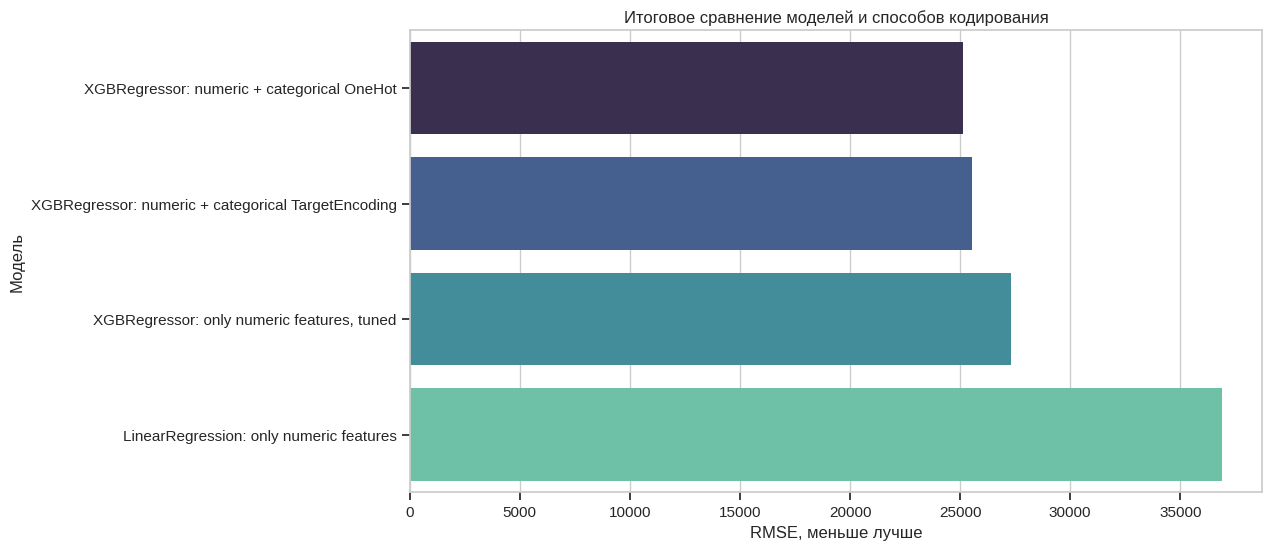

In [15]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(results_df)

plt.figure(figsize=(11, 6))
sns.barplot(data=results_df, x='RMSE', y='model', palette='mako')
plt.title('Итоговое сравнение моделей и способов кодирования')
plt.xlabel('RMSE, меньше лучше')
plt.ylabel('Модель')
plt.show()

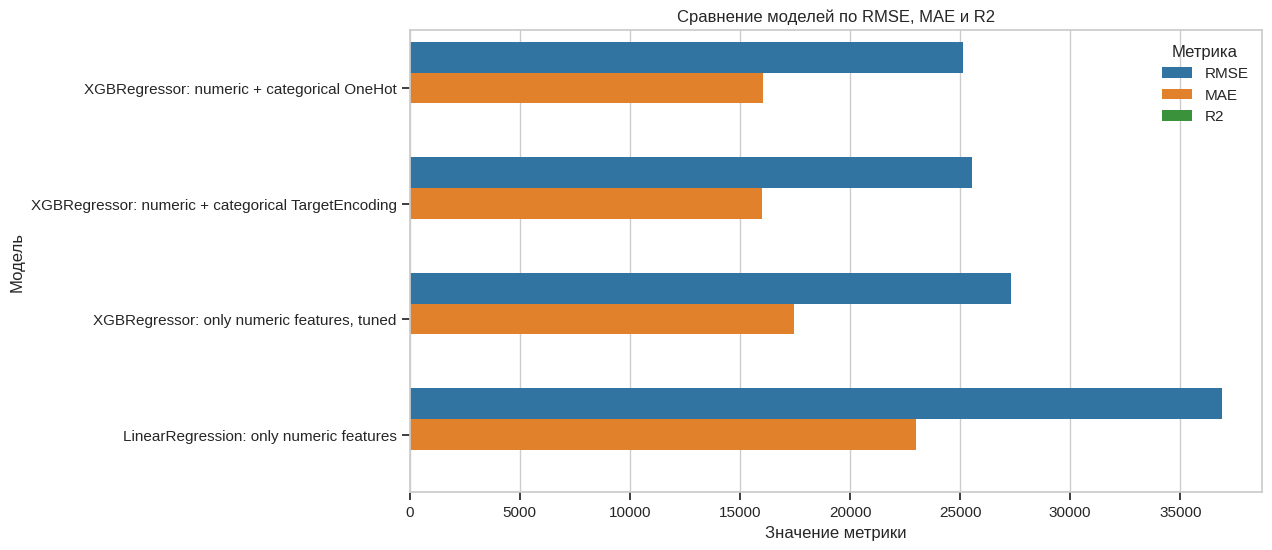

In [16]:
plt.figure(figsize=(11, 6))
plot_df = results_df.melt(id_vars='model', value_vars=['RMSE', 'MAE', 'R2'], var_name='metric', value_name='value')
sns.barplot(data=plot_df, x='value', y='model', hue='metric')
plt.title('Сравнение моделей по RMSE, MAE и R2')
plt.xlabel('Значение метрики')
plt.ylabel('Модель')
plt.legend(title='Метрика')
plt.show()

# 4. Визуализация объектов в пространстве главных компонент

Метод главных компонент (`PCA`) строит новые ортогональные оси, которые максимизируют дисперсию данных. Для визуализации возьмем числовые признаки, заполним пропуски медианами, стандартизируем признаки и отобразим объекты в первых двух главных компонентах.

Цвет точки показывает цену дома. Если в PCA-пространстве виден градиент цвета, значит первые компоненты частично отражают факторы, влияющие на цену.


In [17]:
pca_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=RANDOM_STATE)),
])

principal_components = pca_pipeline.fit_transform(X[numeric_features])
pca_model = pca_pipeline.named_steps['pca']

pca_df = pd.DataFrame({
    'PC1': principal_components[:, 0],
    'PC2': principal_components[:, 1],
    'SalePrice': y,
})

print('Доля объясненной дисперсии первыми двумя компонентами:')
print(f"PC1: {pca_model.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca_model.explained_variance_ratio_[1]:.3f}")
print(f"Суммарно: {pca_model.explained_variance_ratio_.sum():.3f}")

Доля объясненной дисперсии первыми двумя компонентами:
PC1: 0.193
PC2: 0.087
Суммарно: 0.279


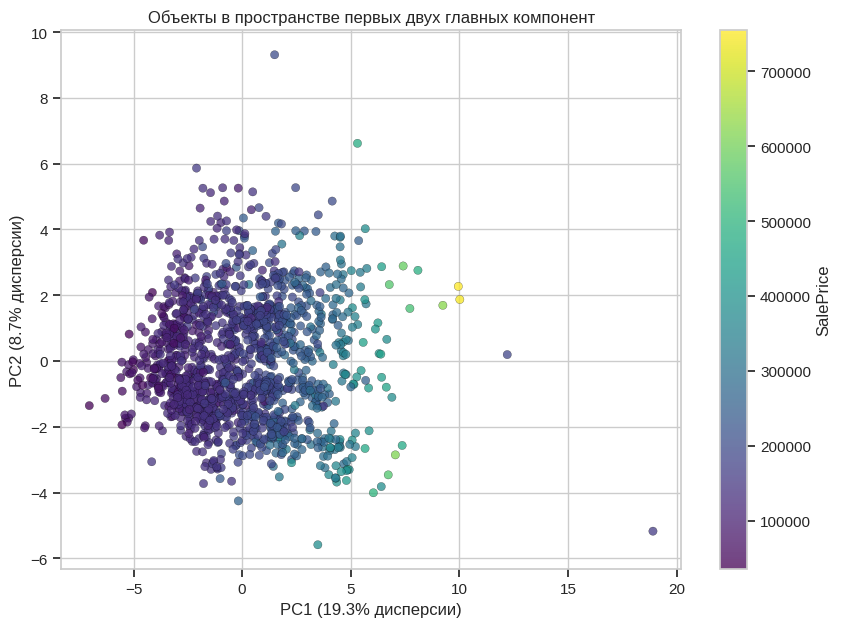

In [18]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['SalePrice'],
    cmap='viridis',
    alpha=0.75,
    edgecolor='k',
    linewidth=0.2,
)
plt.colorbar(scatter, label='SalePrice')
plt.title('Объекты в пространстве первых двух главных компонент')
plt.xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} дисперсии)")
plt.ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} дисперсии)")
plt.show()

In [19]:
# Посмотрим, какие исходные признаки сильнее всего влияют на первые две компоненты.
loadings = pd.DataFrame(
    pca_model.components_.T,
    columns=['PC1', 'PC2'],
    index=numeric_features,
)

for component in ['PC1', 'PC2']:
    print(f'\nНаиболее важные признаки для {component}:')
    display(loadings[component].abs().sort_values(ascending=False).head(10).to_frame('absolute_loading'))


Наиболее важные признаки для PC1:


,absolute_loading
OverallQual,0.301918
GrLivArea,0.299525
GarageCars,0.283248
GarageArea,0.279004
FullBath,0.262047
TotalBsmtSF,0.259202
1stFlrSF,0.257253
TotRmsAbvGrd,0.240754
YearBuilt,0.237633
GarageYrBlt,0.219396



Наиболее важные признаки для PC2:


,absolute_loading
2ndFlrSF,0.430625
BedroomAbvGr,0.363174
TotRmsAbvGrd,0.328618
BsmtFinSF1,0.290605
BsmtFullBath,0.289199
GrLivArea,0.254442
HalfBath,0.222594
TotalBsmtSF,0.212500
YearBuilt,0.197516
KitchenAbvGr,0.174289


# Выводы

1. Линейная регрессия на числовых признаках дает базовое качество и служит интерпретируемым baseline.
2. Бустинг над деревьями обычно улучшает качество, потому что учитывает нелинейности и взаимодействия признаков.
3. Возврат категориальных признаков через one-hot или target encoding позволяет использовать больше информации из таблицы и часто снижает ошибку.
4. One-hot encoding безопасен и хорошо работает при умеренном числе категорий, но увеличивает размерность. Target encoding компактен, однако требует out-of-fold реализации, чтобы не было утечки целевой переменной.
5. PCA позволяет визуально исследовать структуру данных и посмотреть, связаны ли основные направления изменчивости признаков с целевой переменной.
